In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/Users/athipongjindaphram/Documents/ai-job-impact-analysis/ai_job_impact.csv")
df.sample()

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
1614,E1615,50,Female,Master,Healthcare,Nurse,25,Medium,High,Yes,77147,80248,Unchanged,52,No,7,17.59


In [85]:
df_prod_mean_pivot = df.copy()
df_prod_mean = df.copy()
df_prod_mean = df_prod_mean[df_prod_mean["Years_Experience"] > 10]

In [86]:
df_prod_mean_pivot = df_prod_mean_pivot.pivot_table(
    values="Productivity_Change_%",
    aggfunc="mean",
    index="AI_Adoption_Level",
    columns="Remote_Work"
)
df_prod_mean_pivot

Remote_Work,No,Yes
AI_Adoption_Level,,
High,10.580808,11.334162
Low,8.375015,7.649966
Medium,11.450292,8.864491


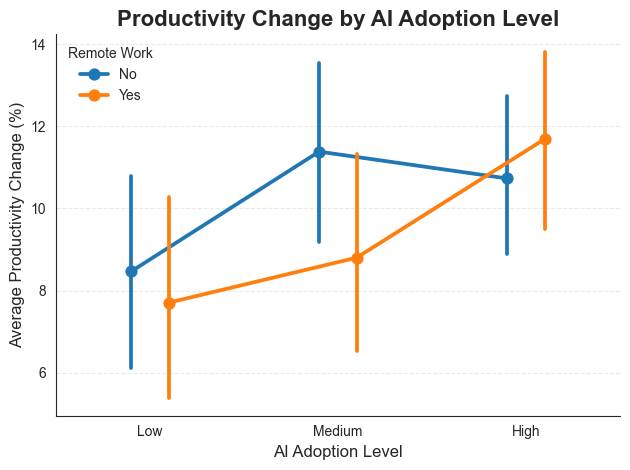

In [87]:
sns.pointplot(
    data=df_prod_mean, 
    x='AI_Adoption_Level', 
    y='Productivity_Change_%', 
    hue='Remote_Work',
    order=['Low', 'Medium', 'High'],
    markers="o",
    linestyles="-",
    dodge=0.2
)
sns.despine()
plt.title(
    'Productivity Change by AI Adoption Level',
    fontsize=16,
    weight='bold'
)
plt.xlabel(
    'AI Adoption Level',
    fontsize=12
)
plt.ylabel(
    'Average Productivity Change (%)',
    fontsize=12
)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)
plt.legend(
    title='Remote Work',
    frameon=False
)
plt.tight_layout()
plt.show()

In [88]:
def calculate_resilience(row):
    if row["Salary_After_AI"] >= row["Salary_Before_AI"]:
        return "Resilient"
    else:
        return "Vulnerable"

In [89]:
df_resi = df.copy()

df_resi["resilience"] = df_resi.apply(calculate_resilience, axis=1)

In [90]:
df_resi_pivot = df_resi.pivot_table(
    values="Employee_ID",
    aggfunc="count",
    index="Education_Level",
    columns="resilience"
)
df_resi_pivot


resilience,Resilient,Vulnerable
Education_Level,,
Bachelor,351,178
High School,338,159
Master,343,165
PhD,317,149


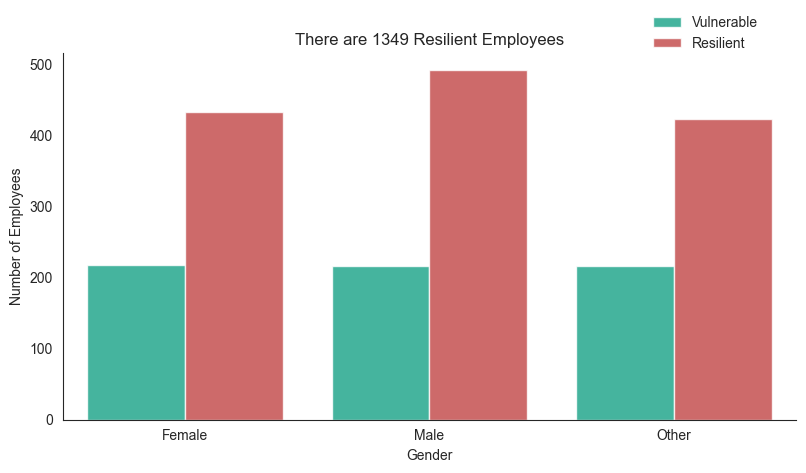

In [ ]:
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'

g = sns.catplot(
    data=df_resi, x='Gender', hue='resilience', kind='count', 
    palette=['#00b894', '#d63031'],
    height=5, aspect=1.4, alpha=0.8
)
sns.despine()
plt.tight_layout()
total = np.sum(df_resi["resilience"] == "Resilient")
plt.title(f"There are {total} Resilient Employees")
sns.move_legend(
    g, "upper right", 
    bbox_to_anchor=(0.95, 0.95),
    ncol=1, 
    title=None,                  
    frameon=False,               
)
plt.subplots_adjust(top=0.85)

g.set_axis_labels("Gender", "Number of Employees")

plt.show()